# Práctica 7: Clustering con K-Means

Para esta séptima práctica, se ejecuta código para realizar modelo K-Means entre los datos.

## Librerías

Se importan las librerías necesarias.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Importación de los datos desde CSV

Se crea una copia del dataset limpio para manejarlo.

In [31]:
# Se carga el conjunto de datos limpio.
df_original = pd.read_csv("C:\\Users\\Paty-\\OneDrive\\Documentos\\04 Facultad\\Séptimo Semestre\\Minería de Datos\\CardiovascularDiseaseDataMining\\Practica1\\cardiovascular_disease_cleaned.csv", sep=";")

# Se crea una copia del conjunto de datos limpio para trabajar en ella.
df = df_original.copy()

# Se muestran las primeras filas del conjunto de datos.
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,birth_date,age_scaled,height_scaled,weight_scaled,ap_hi_scaled,ap_lo_scaled
0,0,50,Male,168,62.0,110,80,Normal,Normal,No,No,Yes,No,1968-10-15 09:32:17.835072,-0.426244,0.477190,-0.911143,-1.149090,-0.221435
1,1,55,Female,156,85.0,140,90,Well Above Normal,Normal,No,No,Yes,Yes,1963-10-07 09:32:17.835072,0.315922,-1.116157,0.963057,0.950300,1.081779
2,2,51,Female,165,64.0,130,70,Well Above Normal,Normal,No,No,No,Yes,1967-07-09 09:32:17.835072,-0.277811,0.078853,-0.748169,0.250504,-1.524649
3,3,48,Male,169,82.0,150,100,Normal,Normal,No,No,Yes,Yes,1970-11-24 09:32:17.835072,-0.723111,0.609969,0.718596,1.650097,2.384993
4,8,59,Female,151,67.0,120,80,Above Normal,Above Normal,No,No,No,No,1959-02-24 09:32:17.835072,0.909656,-1.780052,-0.503708,-0.449293,-0.221435


## Variables independientes a utilizar

In [32]:
X = df[
    [
        'age_scaled',
        'weight_scaled',
        'ap_hi_scaled',
        'ap_lo_scaled'
    ]
]

## Método del codo

Se grafica la inercia del modelo para varios valores de k, y de esta manera si visualiza en qué punto de la gráfica la disminución comienza a minimizarse.

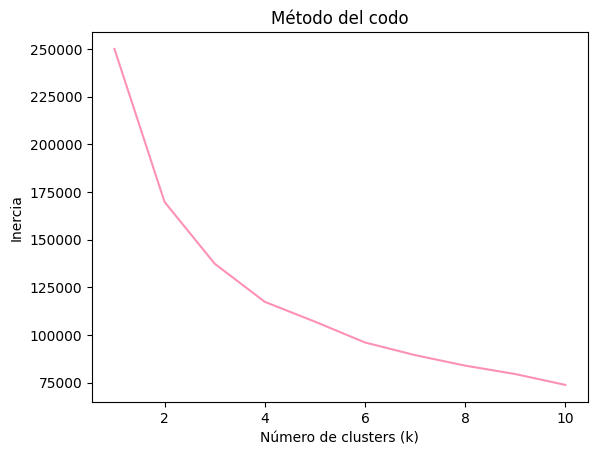

In [36]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, color="#fd91b5")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

#### Elegimos el valor de k

Se elige en base al método del codo.

Además, se realizaron pruebas con valores de k entre 2 y 4 para verificar que se tuviese el mejor resultado posible.

In [34]:
kmeans = KMeans(n_clusters=2, random_state=42)

kmeans.fit(X)

df['cluster'] = kmeans.labels_

#### Evaluamos el modelo

In [35]:
score = silhouette_score(X, df['cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.3207399526119041
